# Duración de la titulación en el pregrado universitario chileno (2025)
Sumativa 1, Fase 2 · MCDI501 · Integrantes: Fernanda Ovalle Román, Sebastián Cajales Cid, César Lorca Bacián, Jorge Álvarez Ossandón.

Fuente: Titulados de Educación Superior 2025 (Mineduc). El archivo crudo debe estar en `data/raw/`.

## 1. Preparación y calidad de datos
Carga del crudo, filtro a pregrado universitario, tratamiento de faltantes (códigos 1900 y 0 → NaN, sin imputar), variables derivadas y marcado de atípicos.

In [1]:
from pathlib import Path
import pandas as pd

# Raíz del repo: el notebook vive en notebooks/, así que subimos un nivel
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUTA_CRUDO = RAIZ / "data" / "raw" / "20260817_Titulados_Ed_Superior_2025_WEB.csv"

crudo = pd.read_csv(RUTA_CRUDO, sep=";", encoding="utf-8", low_memory=False)
print(f"Filas: {crudo.shape[0]:,} | Columnas: {crudo.shape[1]}")

Filas: 328,998 | Columnas: 41


In [2]:
resumen = pd.DataFrame({
    "tipo": crudo.dtypes.astype(str),
    "n_unicos": crudo.nunique(),
    "ejemplo": crudo.iloc[0],
})
resumen

,tipo,n_unicos,ejemplo
cat_periodo,int64,1,2025
cod_sies_obt_tit,str,15469,I23S2C387J1V1
mrun,float64,316077,310.0
gen_alu,int64,2,1
fec_nac_alu,int64,702,199504
rango_edad,str,7,30 a 34 Años
anio_ing_carr_ori,int64,45,2022
sem_ing_carr_ori,int64,3,2
anio_ing_carr_act,int64,42,2023
sem_ing_carr_act,int64,2,2


## 2. Análisis exploratorio de datos
Descriptivos, frecuencias de variables categóricas, correlaciones de Spearman y atraso por grupo.

In [3]:
codigos_relleno = [1900, 0, "Sin Información", "SIN INFORMACION"]

faltantes = pd.DataFrame({
    "nan": crudo.isna().sum(),
    "relleno": crudo.isin(codigos_relleno).sum(),
})
faltantes["total"] = faltantes["nan"] + faltantes["relleno"]
faltantes["pct"] = (100 * faltantes["total"] / len(crudo)).round(2)
faltantes[faltantes["total"] > 0].sort_values("pct", ascending=False)

,nan,relleno,total,pct
dur_proceso_tit,0,216001,216001,65.65
nombre_grado,201664,0,201664,61.30
nombre_titulo,35143,0,35143,10.68
sem_ing_carr_ori,0,18029,18029,5.48
anio_ing_carr_ori,0,18029,18029,5.48
cod_carrera,5471,248,5719,1.74
version,5491,0,5491,1.67
cod_sede,0,1307,1307,0.40
mrun,970,0,970,0.29
rango_edad,0,14,14,0.00


In [4]:
filtro = (crudo["nivel_global"] == "Pregrado") & (crudo["tipo_inst_1"] == "Universidades")
df = crudo.loc[filtro].copy()

print(f"Crudo:      {len(crudo):,} filas")
print(f"Pregrado U: {len(df):,} filas ({100*len(df)/len(crudo):.1f} % del total)")

Crudo:      328,998 filas
Pregrado U: 105,063 filas (31.9 % del total)


In [5]:
relleno_por_columna = {
    "anio_ing_carr_ori": [1900],
    "sem_ing_carr_ori":  [0],
    "rango_edad":        ["Sin Información"],
}

tabla = pd.DataFrame({"nan": df.isna().sum()})
tabla["relleno"] = 0
for col, codigos in relleno_por_columna.items():
    tabla.loc[col, "relleno"] = df[col].isin(codigos).sum()

tabla["total"] = tabla["nan"] + tabla["relleno"]
tabla["pct"] = (100 * tabla["total"] / len(df)).round(2)
tabla[tabla["total"] > 0].sort_values("pct", ascending=False)

,nan,relleno,total,pct
anio_ing_carr_ori,0,13396,13396,12.75
sem_ing_carr_ori,0,13396,13396,12.75
nombre_grado,8437,0,8437,8.03
nombre_titulo,2997,0,2997,2.85
cod_carrera,300,0,300,0.29
version,290,0,290,0.28
mrun,7,0,7,0.01


In [6]:
n_filas_dup = df.duplicated().sum()

conteo_mrun = df["mrun"].value_counts()
n_personas_repetidas = (conteo_mrun > 1).sum()
n_filas_de_repetidos = conteo_mrun[conteo_mrun > 1].sum()

print(f"Filas idénticas:               {n_filas_dup:,}")
print(f"Personas con más de un título: {n_personas_repetidas:,}")
print(f"Filas que aportan esas personas: {n_filas_de_repetidos:,} ({100*n_filas_de_repetidos/len(df):.2f} %)")

Filas idénticas:               0
Personas con más de un título: 461
Filas que aportan esas personas: 922 (0.88 %)


In [7]:
import numpy as np

df["ingreso_sin_info"] = df["anio_ing_carr_ori"].eq(1900)

df["anio_ing_carr_ori"] = df["anio_ing_carr_ori"].replace(1900, np.nan)
df["sem_ing_carr_ori"]  = df["sem_ing_carr_ori"].replace(0, np.nan)

print(f"Filas marcadas sin info de ingreso: {df['ingreso_sin_info'].sum():,}")
print(f"NaN en anio_ing_carr_ori: {df['anio_ing_carr_ori'].isna().sum():,}")

Filas marcadas sin info de ingreso: 13,396
NaN en anio_ing_carr_ori: 13,396


In [8]:
constantes = [col for col in df.columns if df[col].nunique(dropna=False) == 1]
print("Columnas constantes:", constantes)

df = df.drop(columns=constantes)
print(f"Columnas restantes: {df.shape[1]}")

Columnas constantes: ['cat_periodo', 'tipo_inst_1', 'nivel_global']
Columnas restantes: 39


In [9]:
anio_tit = df["fecha_obtencion_titulo"] // 10000
mes_tit  = (df["fecha_obtencion_titulo"] // 100) % 100
sem_tit  = np.where(mes_tit <= 6, 1, 2)

idx_ingreso = df["anio_ing_carr_ori"] * 2 + (df["sem_ing_carr_ori"] - 1)
idx_titulo  = anio_tit * 2 + (sem_tit - 1)

df["semestres_reales"] = idx_titulo - idx_ingreso + 1
df["semestres_reales"].describe()

count    91667.000000
mean        12.986091
std          5.046340
min          1.000000
25%         11.000000
50%         12.000000
75%         14.000000
max        109.000000
Name: semestres_reales, dtype: float64

In [10]:
anio_nac = df["fec_nac_alu"] // 100
mes_nac  = df["fec_nac_alu"] % 100

meses_vividos = (anio_tit * 12 + mes_tit) - (anio_nac * 12 + mes_nac)
df["edad_titulacion"] = meses_vividos / 12
df["edad_titulacion"].describe()

count    105063.000000
mean         27.965639
std           6.407549
min          19.166667
25%          24.083333
50%          25.583333
75%          29.083333
max          80.833333
Name: edad_titulacion, dtype: float64

In [11]:
df["edad_ingreso"] = df["anio_ing_carr_ori"] - anio_nac

df["incons_antes_formal"] = df["semestres_reales"] < df["dur_total_carr"]
df["incons_ingreso_joven"] = df["edad_ingreso"] < 15

def marcar_atipicos(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    ric = q3 - q1
    return (serie < q1 - 1.5 * ric) | (serie > q3 + 1.5 * ric)

df["atipico_semestres"] = marcar_atipicos(df["semestres_reales"])
df["atipico_edad"]      = marcar_atipicos(df["edad_titulacion"])

banderas = ["incons_antes_formal", "incons_ingreso_joven", "atipico_semestres", "atipico_edad"]
df[banderas].sum()

incons_antes_formal      1511
incons_ingreso_joven        0
atipico_semestres       13201
atipico_edad            10711
dtype: int64

In [12]:
calidad = pd.DataFrame([
    ["Filtro de población (pregrado universitario)", len(crudo) - len(df), "Excluidas"],
    ["Filas duplicadas idénticas", n_filas_dup, "Ninguna que eliminar"],
    ["Personas con más de un título", n_filas_de_repetidos, "Conservadas (unidad = titulación)"],
    ["Columnas constantes", len(constantes), "Eliminadas"],
    ["Sin año/semestre de ingreso (1900/0)", df["ingreso_sin_info"].sum(), "NaN + bandera, sin imputar"],
    ["Titulados antes de la duración formal", df["incons_antes_formal"].sum(), "Marcadas"],
    ["Atípicos en semestres reales (Tukey)", df["atipico_semestres"].sum(), "Marcados, no eliminados"],
    ["Atípicos en edad de titulación (Tukey)", df["atipico_edad"].sum(), "Marcados, no eliminados"],
], columns=["Revisión", "Casos", "Decisión"])

calidad["% de la población"] = (100 * calidad["Casos"] / len(df)).round(2)
calidad


,Revisión,Casos,Decisión,% de la población
0,Filtro de población (pregrado universitario),223935,Excluidas,213.14
1,Filas duplicadas idénticas,0,Ninguna que eliminar,0.00
2,Personas con más de un título,922,Conservadas (unidad = titulación),0.88
3,Columnas constantes,3,Eliminadas,0.00
4,Sin año/semestre de ingreso (1900/0),13396,"NaN + bandera, sin imputar",12.75
5,Titulados antes de la duración formal,1511,Marcadas,1.44
6,Atípicos en semestres reales (Tukey),13201,"Marcados, no eliminados",12.56
7,Atípicos en edad de titulación (Tukey),10711,"Marcados, no eliminados",10.19


In [13]:
df["atraso_semestres"] = df["semestres_reales"] - df["dur_total_carr"]

numericas = ["semestres_reales", "dur_total_carr", "atraso_semestres", "edad_titulacion"]

desc = df[numericas].agg(["count", "mean", "median", "std", "min", "max"]).T
desc["Q1"]  = df[numericas].quantile(0.25)
desc["Q3"]  = df[numericas].quantile(0.75)
desc["RIC"] = desc["Q3"] - desc["Q1"]
desc["CV_%"] = 100 * desc["std"] / desc["mean"]
desc["asimetria"] = df[numericas].skew()
desc.round(2)

,count,mean,median,std,min,max,Q1,Q3,RIC,CV_%,asimetria
semestres_reales,91667.0,12.99,12.00,5.05,1.00,109.00,11.00,14.00,3.0,38.86,3.33
dur_total_carr,105063.0,9.07,10.00,2.44,1.00,24.00,8.00,10.00,2.0,26.90,-0.99
atraso_semestres,91667.0,3.40,2.00,4.76,-10.00,98.00,1.00,4.00,3.0,140.07,4.41
edad_titulacion,105063.0,27.97,25.58,6.41,19.17,80.83,24.08,29.08,5.0,22.91,2.22


C:\Users\jorge\AppData\Local\Temp\ipykernel_27160\2426515472.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ejes[1, col].boxplot(datos, vert=False, widths=0.6,
C:\Users\jorge\AppData\Local\Temp\ipykernel_27160\2426515472.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ejes[1, col].boxplot(datos, vert=False, widths=0.6,


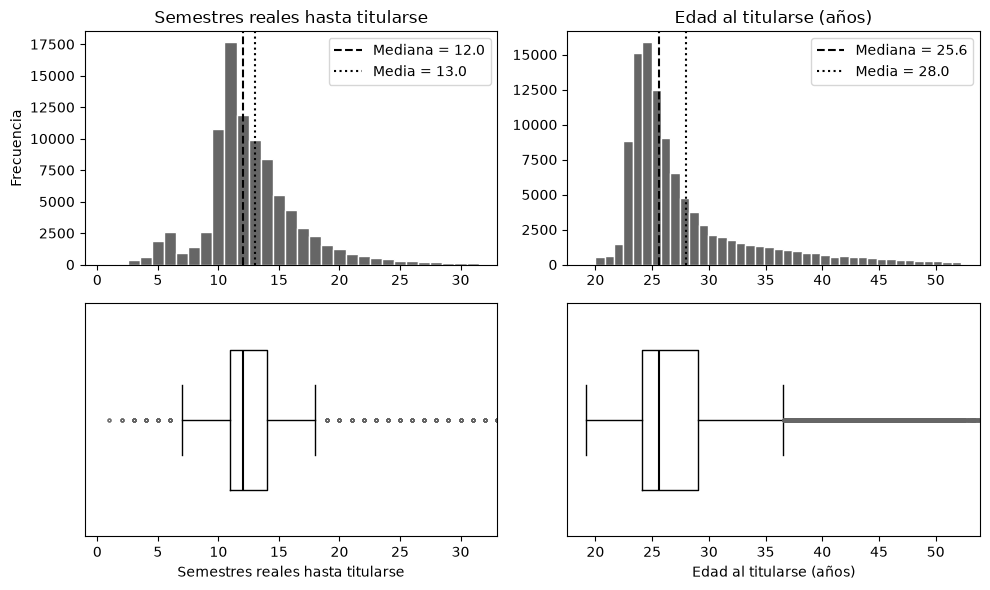

In [15]:
import numpy as np
import matplotlib.pyplot as plt

RUTA_FIG = RAIZ / "informe" / "figuras"

fig, ejes = plt.subplots(2, 2, figsize=(10, 6))
variables = [("semestres_reales", "Semestres reales hasta titularse", True),
             ("edad_titulacion", "Edad al titularse (años)", False)]

for col, (var, titulo, es_discreta) in enumerate(variables):
    datos = df[var].dropna()
    tope = datos.quantile(0.99)

    if es_discreta:
        bins = np.arange(datos.min() - 0.5, tope + 1.5, 1)
    else:
        bins = 40

    ejes[0, col].hist(datos[datos <= tope], bins=bins, color="0.4", edgecolor="white")
    ejes[0, col].axvline(datos.median(), color="black", linestyle="--", label=f"Mediana = {datos.median():.1f}")
    ejes[0, col].axvline(datos.mean(), color="black", linestyle=":", label=f"Media = {datos.mean():.1f}")
    ejes[0, col].set_title(titulo)
    ejes[0, col].legend()

    ejes[1, col].boxplot(datos, vert=False, widths=0.6,
                         medianprops=dict(color="black", linewidth=1.5),
                         flierprops=dict(marker="o", markersize=2, alpha=0.15, markeredgecolor="0.4"))
    ejes[1, col].set_xlim(ejes[0, col].get_xlim())
    ejes[1, col].set_xlabel(titulo)
    ejes[1, col].set_yticks([])

ejes[0, 0].set_ylabel("Frecuencia")
fig.tight_layout()
fig.savefig(RUTA_FIG / "fig_distribuciones.png", dpi=300)
plt.show()

In [16]:
df["sexo"] = df["gen_alu"].map({1: "Hombre", 2: "Mujer"})

categoricas = {
    "tipo_inst_3": "Tipo de universidad",
    "jornada": "Jornada",
    "modalidad": "Modalidad",
    "area_conocimiento": "Área de conocimiento",
    "region_sede": "Región de la sede",
    "sexo": "Sexo",
    "rango_edad": "Rango etario",
}

def frecuencias(col):
    abs_ = df[col].value_counts(dropna=False)
    rel_ = df[col].value_counts(normalize=True, dropna=False) * 100
    return pd.DataFrame({"n": abs_, "%": rel_.round(2)})

for col, nombre in categoricas.items():
    print(f"\n=== {nombre} ({col}) ===")
    print(frecuencias(col).to_string())


=== Tipo de universidad (tipo_inst_3) ===
                                   n      %
tipo_inst_3                                
Universidades Privadas         49491  47.11
Universidades Privadas CRUCH   29164  27.76
Universidades Estatales CRUCH  26408  25.14

=== Jornada (jornada) ===
                    n      %
jornada                     
Diurna          82197  78.24
Vespertina      12431  11.83
A Distancia      9064   8.63
Semipresencial    828   0.79
Otra              543   0.52

=== Modalidad (modalidad) ===
                    n      %
modalidad                   
Presencial      94874  90.30
No Presencial    9064   8.63
Semipresencial   1125   1.07

=== Área de conocimiento (area_conocimiento) ===
                               n      %
area_conocimiento                      
Tecnología                 23705  22.56
Salud                      22506  21.42
Ciencias Sociales          16371  15.58
Administración y Comercio  14295  13.61
Educación                  11833  11.26
D

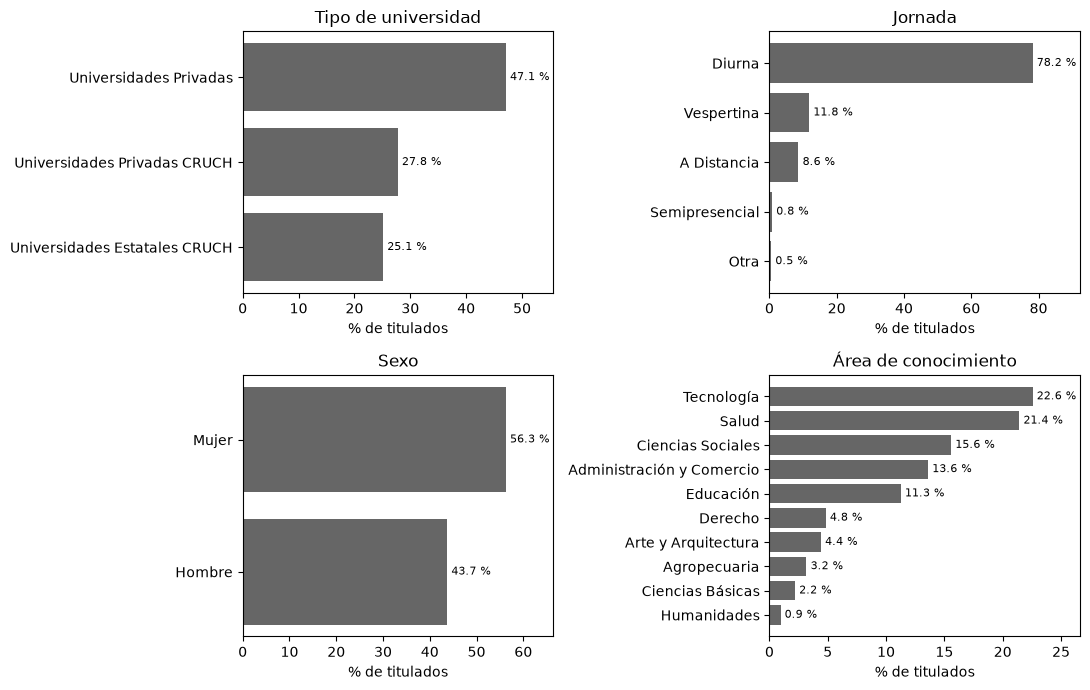

In [17]:
fig, ejes = plt.subplots(2, 2, figsize=(11, 7))
paneles = [("tipo_inst_3", "Tipo de universidad"),
           ("jornada", "Jornada"),
           ("sexo", "Sexo"),
           ("area_conocimiento", "Área de conocimiento")]

for ax, (col, titulo) in zip(ejes.flat, paneles):
    rel = df[col].value_counts(normalize=True).sort_values() * 100
    barras = ax.barh(rel.index, rel.values, color="0.4")
    ax.bar_label(barras, fmt="%.1f %%", padding=3, fontsize=8)
    ax.set_title(titulo)
    ax.set_xlabel("% de titulados")
    ax.set_xlim(0, rel.max() * 1.18)

fig.tight_layout()
fig.savefig(RUTA_FIG / "fig_categoricas.png", dpi=300)
plt.show()

In [18]:
vars_corr = ["semestres_reales", "dur_total_carr", "atraso_semestres", "edad_titulacion"]

pearson  = df[vars_corr].corr(method="pearson").round(2)
spearman = df[vars_corr].corr(method="spearman").round(2)

print("Pearson:")
print(pearson.to_string())
print("\nSpearman:")
print(spearman.to_string())

Pearson:
                  semestres_reales  dur_total_carr  atraso_semestres  edad_titulacion
semestres_reales              1.00            0.34              0.91             0.31
dur_total_carr                0.34            1.00             -0.07            -0.36
atraso_semestres              0.91           -0.07              1.00             0.41
edad_titulacion               0.31           -0.36              0.41             1.00

Spearman:
                  semestres_reales  dur_total_carr  atraso_semestres  edad_titulacion
semestres_reales              1.00            0.48              0.82             0.46
dur_total_carr                0.48            1.00              0.01            -0.19
atraso_semestres              0.82            0.01              1.00             0.47
edad_titulacion               0.46           -0.19              0.47             1.00


In [19]:
df["zona"] = np.where(df["region_sede"] == "Metropolitana", "Metropolitana", "Otras regiones")

grupos = ["tipo_inst_3", "jornada", "sexo", "zona"]
for col in grupos:
    resumen = df.groupby(col)["atraso_semestres"].agg(
        n="count", media="mean", mediana="median",
        Q1=lambda s: s.quantile(0.25), Q3=lambda s: s.quantile(0.75)
    ).round(2).sort_values("mediana")
    print(f"\n=== Atraso por {col} ===")
    print(resumen.to_string())


=== Atraso por tipo_inst_3 ===
                                   n  media  mediana   Q1   Q3
tipo_inst_3                                                   
Universidades Estatales CRUCH  25651   4.01      2.0  1.0  5.0
Universidades Privadas         37741   2.98      2.0  1.0  4.0
Universidades Privadas CRUCH   28275   3.40      2.0  1.0  4.0

=== Atraso por jornada ===
                    n  media  mediana   Q1   Q3
jornada                                        
A Distancia      2182   3.52      1.0  1.0  3.0
Otra              263   3.06      1.0  1.0  4.0
Semipresencial    380   2.20      1.0  1.0  2.0
Diurna          81001   3.27      2.0  1.0  4.0
Vespertina       7841   4.75      2.0  1.0  7.0

=== Atraso por sexo ===
            n  media  mediana   Q1   Q3
sexo                                   
Hombre  40075   4.00      2.0  1.0  5.0
Mujer   51592   2.93      2.0  1.0  4.0

=== Atraso por zona ===
                    n  media  mediana   Q1   Q3
zona                           

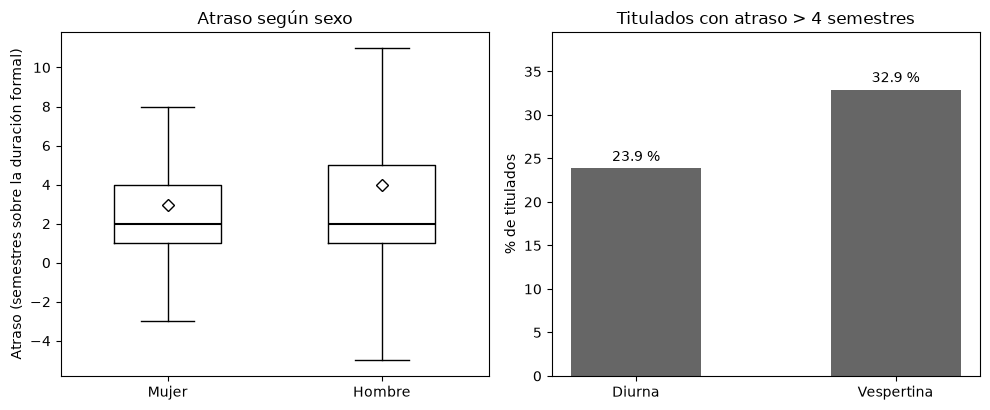

jornada
Diurna        23.9
Vespertina    32.9
Name: atraso_alto, dtype: float64


In [20]:
UMBRAL_ALTO = 4
df["atraso_alto"] = df["atraso_semestres"] > UMBRAL_ALTO

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))

orden_sexo = ["Mujer", "Hombre"]
datos_sexo = [df.loc[df["sexo"] == s, "atraso_semestres"].dropna() for s in orden_sexo]
ax1.boxplot(datos_sexo, tick_labels=orden_sexo, widths=0.5, showfliers=False, showmeans=True,
            medianprops=dict(color="black", linewidth=1.5),
            meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black"))
ax1.set_title("Atraso según sexo")
ax1.set_ylabel("Atraso (semestres sobre la duración formal)")

jornadas = ["Diurna", "Vespertina"]
sub = df[df["jornada"].isin(jornadas) & df["atraso_semestres"].notna()]
pct_alto = sub.groupby("jornada")["atraso_alto"].mean().reindex(jornadas) * 100
barras = ax2.bar(jornadas, pct_alto, color="0.4", width=0.5)
ax2.bar_label(barras, fmt="%.1f %%", padding=3)
ax2.set_title(f"Titulados con atraso > {UMBRAL_ALTO} semestres")
ax2.set_ylabel("% de titulados")
ax2.set_ylim(0, pct_alto.max() * 1.2)

fig.tight_layout()
fig.savefig(RUTA_FIG / "fig_bivariado.png", dpi=300)
plt.show()
print(pct_alto.round(1))

## 3. Estimación de parámetros

In [21]:
from scipy import stats

VARS_EST = ["atraso_semestres", "semestres_reales", "edad_titulacion"]

def ic_media_t(x, conf=0.95):
    x = x.dropna()
    n = len(x)
    media = x.mean()
    ee = x.std(ddof=1) / np.sqrt(n)            # error estándar de la media
    tcrit = stats.t.ppf((1 + conf) / 2, df=n - 1)
    return n, media, ee, media - tcrit * ee, media + tcrit * ee

filas = []
for v in VARS_EST:
    n, m, ee, li, ls = ic_media_t(df[v])
    filas.append({"variable": v, "n": n, "media": m, "ee": ee,
                  "IC95_inf": li, "IC95_sup": ls})

tabla_ic_media = pd.DataFrame(filas).set_index("variable")
tabla_ic_media.round(3)

,n,media,ee,IC95_inf,IC95_sup
variable,,,,,
atraso_semestres,91667,3.398,0.016,3.367,3.429
semestres_reales,91667,12.986,0.017,12.953,13.019
edad_titulacion,105063,27.966,0.020,27.927,28.004


In [22]:
rng = np.random.default_rng(42)   # semilla fija: resultado reproducible
B = 2000                          # número de remuestras

def ic_mediana_boot(x, B=B, conf=0.95):
    x = x.dropna().to_numpy()
    n = len(x)
    medianas = np.empty(B)
    for b in range(B):
        muestra = rng.choice(x, size=n, replace=True)
        medianas[b] = np.median(muestra)
    alfa = 1 - conf
    li, ls = np.percentile(medianas, [100 * alfa / 2, 100 * (1 - alfa / 2)])
    return n, np.median(x), li, ls

filas = []
for v in VARS_EST:
    n, med, li, ls = ic_mediana_boot(df[v])
    filas.append({"variable": v, "n": n, "mediana": med,
                  "IC95_inf": li, "IC95_sup": ls})

tabla_ic_mediana = pd.DataFrame(filas).set_index("variable")
tabla_ic_mediana.round(3)

,n,mediana,IC95_inf,IC95_sup
variable,,,,
atraso_semestres,91667,2.000,2.000,2.000
semestres_reales,91667,12.000,12.000,12.000
edad_titulacion,105063,25.583,25.583,25.667


In [23]:
tabla_ic = pd.DataFrame({
    "n": tabla_ic_media["n"],
    "Media": tabla_ic_media["media"],
    "IC95 media": tabla_ic_media.apply(
        lambda r: f"[{r.IC95_inf:.2f}; {r.IC95_sup:.2f}]", axis=1),
    "Mediana": tabla_ic_mediana["mediana"],
    "IC95 mediana (boot)": tabla_ic_mediana.apply(
        lambda r: f"[{r.IC95_inf:.2f}; {r.IC95_sup:.2f}]", axis=1),
})
tabla_ic.round(2)

,n,Media,IC95 media,Mediana,IC95 mediana (boot)
variable,,,,,
atraso_semestres,91667,3.40,[3.37; 3.43],2.00,[2.00; 2.00]
semestres_reales,91667,12.99,[12.95; 13.02],12.00,[12.00; 12.00]
edad_titulacion,105063,27.97,[27.93; 28.00],25.58,[25.58; 25.67]


## 4. Pruebas de hipótesis
### Prueba 1: atraso según sexo (t de Welch)

In [24]:
ALFA = 0.05

h = df.loc[df["sexo"] == "Hombre", "atraso_semestres"].dropna()
m = df.loc[df["sexo"] == "Mujer",  "atraso_semestres"].dropna()

# Descriptivos por grupo
print(f"Hombres: n={len(h):,}  media={h.mean():.3f}  sd={h.std():.3f}  mediana={h.median():.1f}")
print(f"Mujeres: n={len(m):,}  media={m.mean():.3f}  sd={m.std():.3f}  mediana={m.median():.1f}")

# Supuesto: igualdad de varianzas (Levene, centrado en la mediana)
lev = stats.levene(h, m, center="median")
print(f"\nLevene: W={lev.statistic:.2f}  p={lev.pvalue:.2e}")

# Prueba principal: t de Welch (no asume varianzas iguales)
welch = stats.ttest_ind(h, m, equal_var=False)
print(f"Welch:  t={welch.statistic:.2f}  gl={welch.df:,.0f}  p={welch.pvalue:.2e}")

# IC 95% de la diferencia de medias (Welch)
ic_dif = welch.confidence_interval(confidence_level=0.95)
print(f"Diferencia de medias = {h.mean()-m.mean():.3f}  IC95% [{ic_dif.low:.3f}; {ic_dif.high:.3f}]")

# Respaldo no paramétrico
mw = stats.mannwhitneyu(h, m, alternative="two-sided")
print(f"Mann-Whitney: U={mw.statistic:.3e}  p={mw.pvalue:.2e}")

# Tamaño del efecto: d de Cohen con desviación estándar combinada
sp = np.sqrt(((len(h)-1)*h.var() + (len(m)-1)*m.var()) / (len(h)+len(m)-2))
d = (h.mean() - m.mean()) / sp
print(f"d de Cohen = {d:.3f}")
print("Decisión:", "Rechazar H0" if welch.pvalue < ALFA else "No rechazar H0")

Hombres: n=40,075  media=3.999  sd=5.434  mediana=2.0
Mujeres: n=51,592  media=2.931  sd=4.101  mediana=2.0

Levene: W=735.72  p=2.22e-161
Welch:  t=32.76  gl=72,374  p=1.09e-233
Diferencia de medias = 1.068  IC95% [1.004; 1.132]
Mann-Whitney: U=1.194e+09  p=0.00e+00
d de Cohen = 0.226
Decisión: Rechazar H0


### Prueba 2: jornada y atraso alto (chi-cuadrado de independencia)

In [25]:
sub = df.loc[df["jornada"].isin(["Diurna", "Vespertina"]) & df["atraso_semestres"].notna()]

tabla = pd.crosstab(sub["jornada"], sub["atraso_alto"])
print("Frecuencias observadas:\n", tabla, "\n")
print("% con atraso alto por jornada:\n",
      (pd.crosstab(sub["jornada"], sub["atraso_alto"], normalize="index") * 100).round(1), "\n")

chi2, p, gl, esperadas = stats.chi2_contingency(tabla, correction=False)
print("Frecuencias esperadas bajo H0:\n", np.round(esperadas, 0))
print(f"Mínima esperada = {esperadas.min():,.0f}  (supuesto: todas > 5)\n")

print(f"Chi-cuadrado = {chi2:.2f}  gl={gl}  p={p:.2e}")

# Tamaño del efecto: V de Cramér
n_tot = tabla.to_numpy().sum()
v = np.sqrt(chi2 / (n_tot * (min(tabla.shape) - 1)))
print(f"V de Cramér = {v:.3f}")
print("Decisión:", "Rechazar H0" if p < ALFA else "No rechazar H0")

Frecuencias observadas:
 atraso_alto  False  True 
jornada                  
Diurna       61679  19322
Vespertina    5260   2581 

% con atraso alto por jornada:
 atraso_alto  False  True 
jornada                  
Diurna        76.1   23.9
Vespertina    67.1   32.9 

Frecuencias esperadas bajo H0:
 [[61031. 19970.]
 [ 5908.  1933.]]
Mínima esperada = 1,933  (supuesto: todas > 5)

Chi-cuadrado = 316.09  gl=1  p=1.03e-70
V de Cramér = 0.060
Decisión: Rechazar H0
